### **[Linear Regression for Time Series with Unit Root and Cointegration Testing](https://medium.com/@kyle-t-jones/f78584d54eaf)**

In [1]:
import sys

import warnings
warnings.filterwarnings("ignore")

IN_COLAB = "google.colab" in sys.modules

from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
np.set_printoptions(precision=3, suppress=True)

pd.set_option("display.max_columns", 10)
pd.set_option("display.max_rows", 10)
pd.set_option("display.width", 100)
pd.set_option("display.colheader_justify", "left")
pd.set_option("display.precision", 3)
pd.set_option("display.float_format", "{:.3f}".format)

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

%autosave 15

Autosaving every 15 seconds


,y1,y2,y3
0,0.497,10.179,-0.797
1,0.358,10.459,-0.200
2,1.006,11.001,0.201
3,2.529,11.528,0.319
4,2.295,10.839,0.164
...,...,...,...
195,-6.339,18.205,0.351
196,-7.223,17.348,0.547
197,-7.069,18.025,0.262
198,-7.011,17.968,0.592


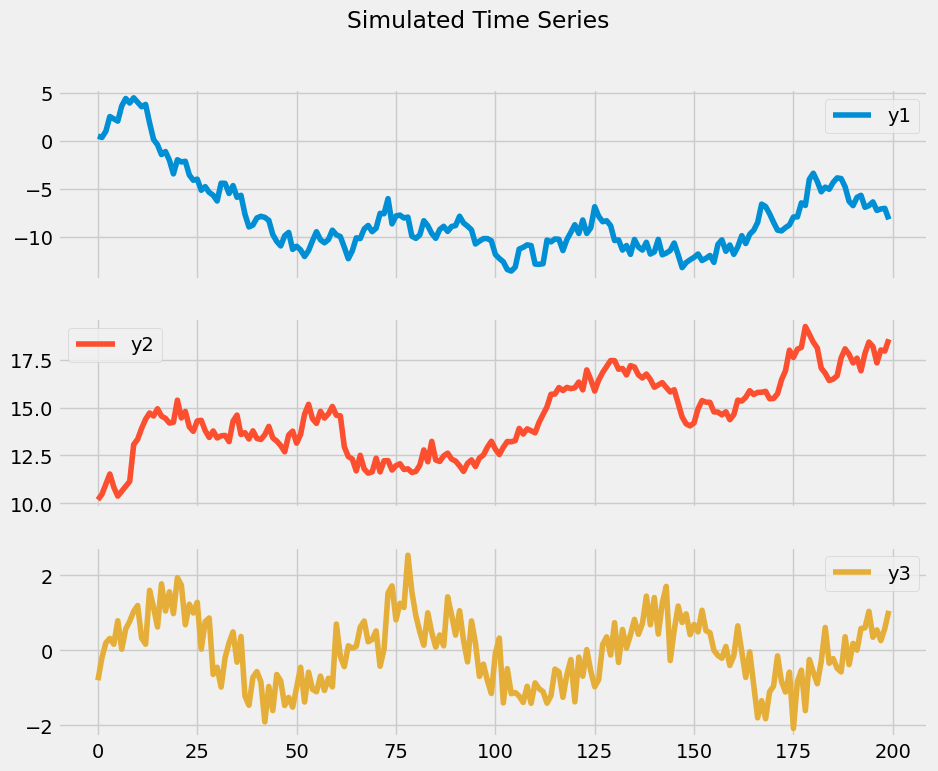

In [2]:
n = 200
t = np.arange(n)

y1 = np.cumsum(np.random.normal(size=n))
y2 = 0.5 * np.cumsum(np.random.normal(size=n)) + 10
y3 = np.sin(t / 10) + np.random.normal(scale=0.5, size=n)

data = pd.DataFrame({"y1": y1, "y2": y2, "y3": y3})
display(data)

data.plot(subplots=True, figsize=(10, 8), title="Simulated Time Series")
plt.show()

In [3]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
  result = adfuller(series)
  print(f"ADF Test for {name}:")
  print(f"Test Statistic: {result[0]:.4f}")
  print(f"P-Value: {result[1]:.4f}")
  if result[1] > 0.05:
    print(f"{name} has a unit root (non-stationary).\n")
  else:
    print(f"{name} is stationary.\n")

adf_test(data["y1"], "y1")
adf_test(data["y2"], "y2")
adf_test(data["y3"], "y3")

ADF Test for y1:
Test Statistic: -2.3073
P-Value: 0.1696
y1 has a unit root (non-stationary).

ADF Test for y2:
Test Statistic: -1.8198
P-Value: 0.3707
y2 has a unit root (non-stationary).

ADF Test for y3:
Test Statistic: -4.4490
P-Value: 0.0002
y3 is stationary.



In [4]:
from statsmodels.api import OLS
from statsmodels.tsa.stattools import coint

model = OLS(data["y1"], data["y2"]).fit()
residuals = model.resid
adf_test(residuals, "Residuals of y1 ~ y2")
coint_stat, p_value, critical_values = coint(data["y1"], data["y2"])
print("Engle-Granger Cointegration Test:")
print(f"Test Statistic: {coint_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Critical Values: {critical_values}")

if p_value < 0.05:
  print("y1 and y2 are cointegrated.\n")
else:
  print("y1 and y2 are not cointegrated.\n")

ADF Test for Residuals of y1 ~ y2:
Test Statistic: -2.1540
P-Value: 0.2233
Residuals of y1 ~ y2 has a unit root (non-stationary).

Engle-Granger Cointegration Test:
Test Statistic: -2.1745
P-Value: 0.4376
Critical Values: [-3.952 -3.367 -3.066]
y1 and y2 are not cointegrated.



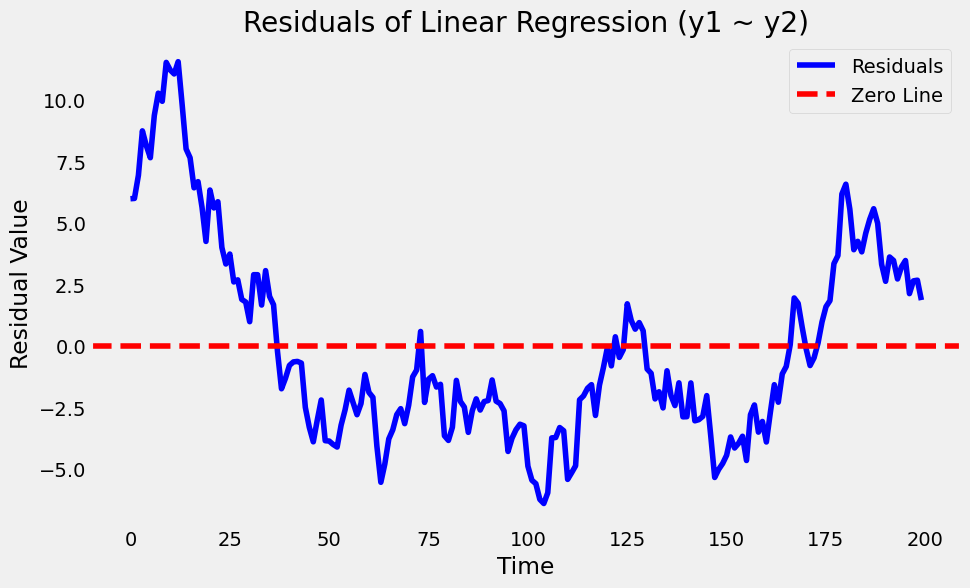

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(residuals, label="Residuals", color="blue")
plt.axhline(0, linestyle="--", color="red", label="Zero Line")
plt.title("Residuals of Linear Regression (y1 ~ y2)")
plt.xlabel("Time")
plt.ylabel("Residual Value")
plt.legend()
plt.grid()
plt.show()